# Computational Modeling Project 8

we use the Fast Fourier Transform (FFT) to look at the 1 dimensional wavepacket, given by the following gaussian pulse,

$$ f(x) = e^{\dfrac{-x^2}{2\sigma^2}}\cos(k_0 x) $$

In [253]:
import numpy as np 
import matplotlib.pyplot as plt

In [254]:

def f(x, sigma=1, k_0=15):
    p = (-x**2)/(2 * (sigma ** 2))
    return (np.exp(p)) * np.cos(k_0 * x)

for $\sigma = 1.0$ the width of the envelope and $k_0 = 15.0$ is the carrier wavenumber, on the domain $x \in [-10, 10]$.

We create two different grids for $x \in [-10, 10]$. One fine with $N = 512$, and 'coarse' grid with $N = 40$. 



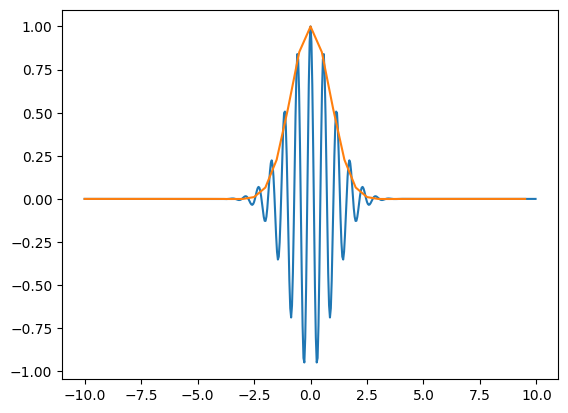

In [255]:
grid_F = np.linspace(-10, 10, 512, endpoint=False)
grid_C = np.linspace(-10, 10, 40, endpoint=False)

plt.plot(grid_F, f(grid_F, 1, 150))
plt.plot(grid_C, f(grid_C, 1, 100)) 


The spatial step size is given by 
$$(\Delta x)_1 = 20/512 = 0.039$$
$$(\Delta x)_2 = 20/40 = 0.5$$

and the corresponding $k_{Nyquist} = \dfrac{\pi}{\Delta  x}$:

$$(k_{Nyquist})_1 = \dfrac{\pi}{(\Delta  x)_1} =  80.42$$
$$(k_{Nyquist})_2 = \dfrac{\pi}{(\Delta  x)_2} =  6.28$$




In [256]:
N_F = 512
N_C = 40

dx1 = 20 / N_F
dx2 = 20 / N_C

kNyquist1 = np.pi/dx1
kNyquist2 = np.pi/dx2

kNyquist1, kNyquist2


(80.4247719318987, 6.283185307179586)

Now we want to apply the Fast Fourier Transform (from scipy) to our function f(x) on both different grids, let us first generate the sets of the image of our domain, given each grid, and then apply fourier transform to it. that way we produce `f_F`,`f_C` representing the fine and coarse versions of the image, respectively. Then apply FFT to get the lists for `ftilde_F`,`ftilde_C`. Finally take the magnitude and plot it against the wave number $k$


/Users/pabo/1.2_Academics/1.20 ComputationalModeling/.venv/lib/python3.9/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/pabo/1.2_Academics/1.20 ComputationalModeling/.venv/lib/python3.9/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


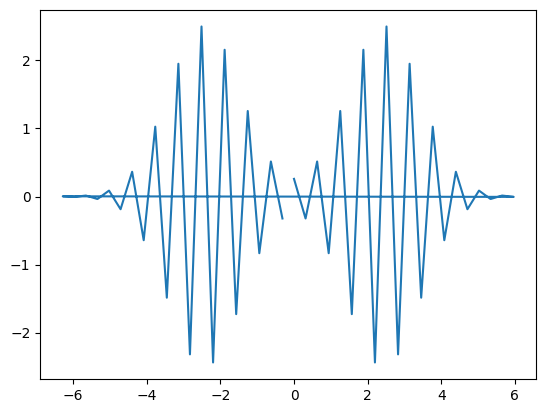

In [257]:
from scipy.fft import fft, fftfreq, fftshift
sigma = 1
k = 15

f_F = f(grid_F)
f_C = f(grid_C)

ftilde_F = fft(f_F)
ftilde_C = fft(f_C)

k_F = 2*np.pi*fftfreq(N_F, d=dx1)
k_C = 2*np.pi*fftfreq(N_C, d=dx2)

plt.plot(k_C, ftilde_C)

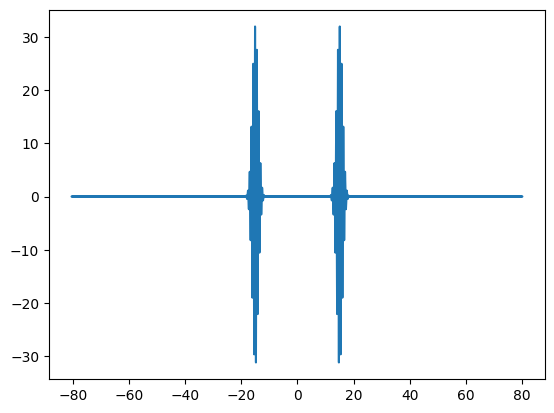

In [258]:
plt.plot(k_F, ftilde_F)

Algebraically we expect a peak at $ k = \pm 15 = k_0$ because of the cosine term having $k_0$ 15.00 aas the carrier wavenumber. In the fine grid, our value $Nyquist$ wave number is much greater than the carrier wave number. For the coarser grid, the value is $\approx 6.3 < k_0$. This means it cannot be represented and the data becomes wrong!

# Part (b)

We want to find the derivative using the FFT, so just do:

$$
f'(x)=\mathcal{F}^{-1}\{ik\tilde f(k)\}.
$$

In [259]:
df_Fourier = np.fft.ifft(1j * k_F * ftilde_F)

we want to corroborate that it is equal to the explicit definition from calculus using the product rule:

$$ f'(x) = e^{-\dfrac{x^2}{2\sigma^2}}(-\dfrac{x}{\sigma^2}\cos(k_0 x)- k_0 \sin(k_0 x))$$

In [260]:
def df(x, sigma=1.0, k_0=15.0):
    p = np.exp(-x**2 / (2*sigma**2))
    return p * (-(x/sigma**2)*np.cos(k_0*x)- k_0*np.sin(k_0*x))

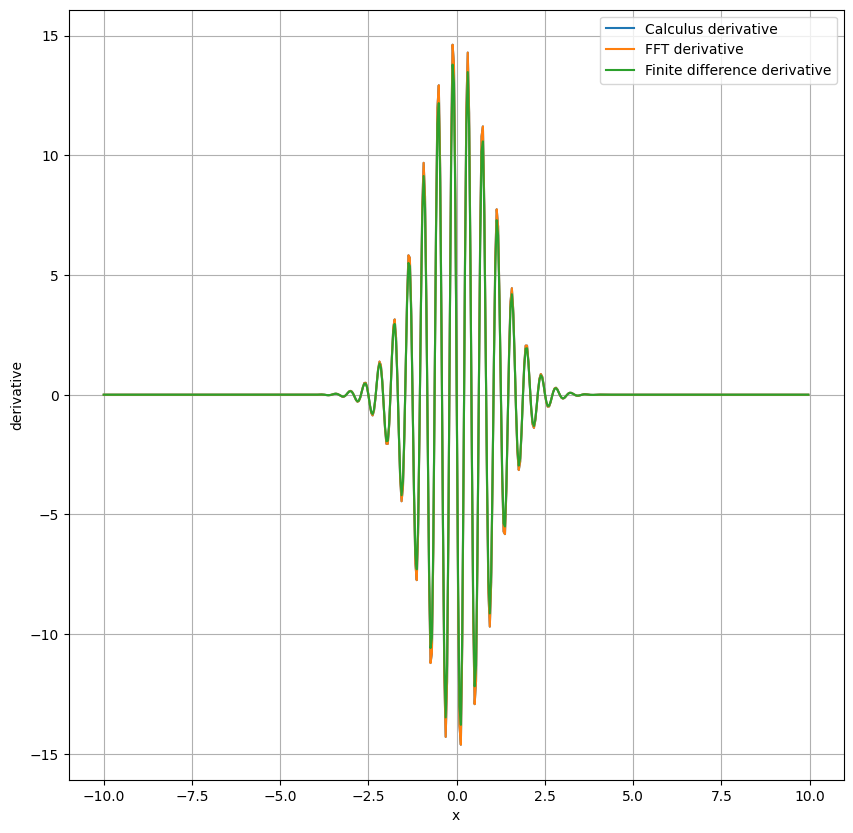

In [261]:
df_fd = np.gradient(f_F, dx1)

df_ex = df(grid_F)

plt.figure(figsize=(10,10))
plt.plot(grid_F, df_ex, label="Calculus derivative")
plt.plot(grid_F, df_Fourier, label="FFT derivative")
plt.plot(grid_F, df_fd, label="Finite difference derivative")
plt.xlabel("x")
plt.ylabel("derivative")
plt.legend()
plt.grid(True)
plt.show()



The error plot is done by the absolute difference between the difference derivative magnitudes

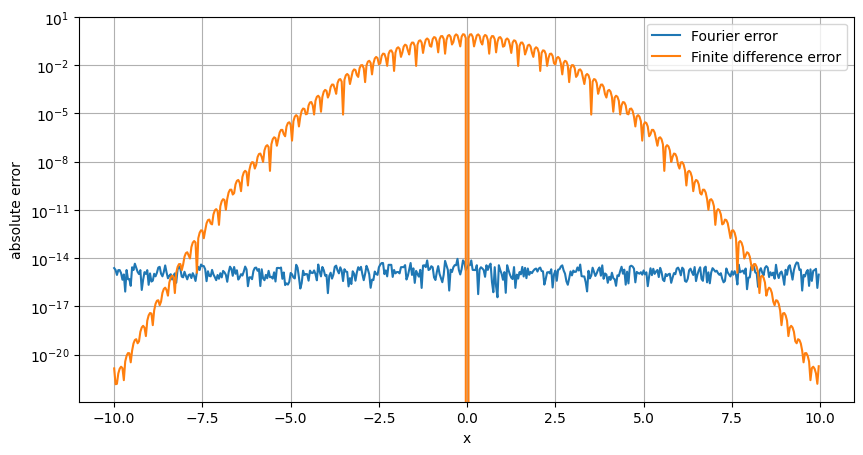

In [262]:
plt.figure(figsize=(10,5))
plt.semilogy(grid_F, np.abs(df_Fourier - df_ex), label="Fourier error")
plt.semilogy(grid_F, np.abs(df_fd - df_ex), label="Finite difference error")
plt.xlabel("x")
plt.ylabel("absolute error")
plt.legend()
plt.grid(True)
plt.show()

# Part (c)

We perform a shift using the shift theorem bby applying a fourier transform and multiplying by $e^{-ikx_0}$

In [263]:
x0 = 3.2
f_shift = np.fft.ifft(np.exp(-1j * k_F * x0) * ftilde_F)

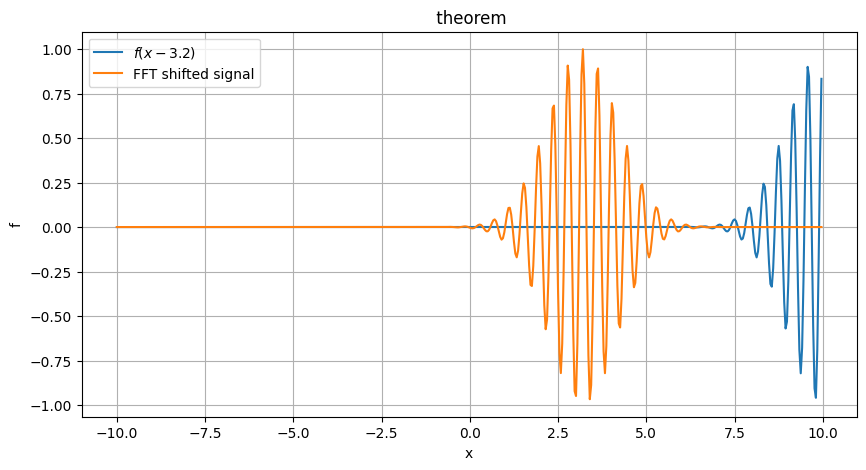

In [264]:
f_shift_ex = f(grid_F - 10)

plt.figure(figsize=(10,5))
plt.plot(grid_F, f_shift_ex, label=r"$f(x-3.2)$")
plt.plot(grid_F, f_shift, label="FFT shifted signal")
plt.xlabel("x")
plt.ylabel("f")
plt.title(" theorem")
plt.legend()
plt.grid(True)
plt.show()

They match perfectly! if given the same value for $x_0$ however the fundamental difference is that the FFT assumes that the boundary is periodic so when translated it will wrap around, but the function provided by `f` is the value over the whole domain of $\mathbb{R}$.

# Part (d)

In [265]:
import time

In [266]:
p_list = np.arange(10, 23)
print(p_list)
N_list = 2**p_list
times = []

for N in Ns:
    random = np.random.rand(N)

    np.fft.fft(random)

    start = time.perf_counter()
    np.fft.fft(random)
    end = time.perf_counter()

    times.append(end - start)

times = np.array(times)
times

[10 11 12 13 14 15 16 17 18 19 20 21 22]


array([1.09917000e-04, 1.37209001e-04, 2.84589987e-05, 2.00750001e-04,
       1.32083000e-04, 6.45041999e-04, 7.30125001e-04, 2.11437500e-03,
       5.52566700e-03, 8.53804200e-03, 2.16837090e-02, 4.52272500e-02,
       8.64614580e-02])

Now we plot $T$vs$N$ on a log-log scale. We can use the reference line $T_r = cN\log_2(N)$ choice of c is arbitrary for the data

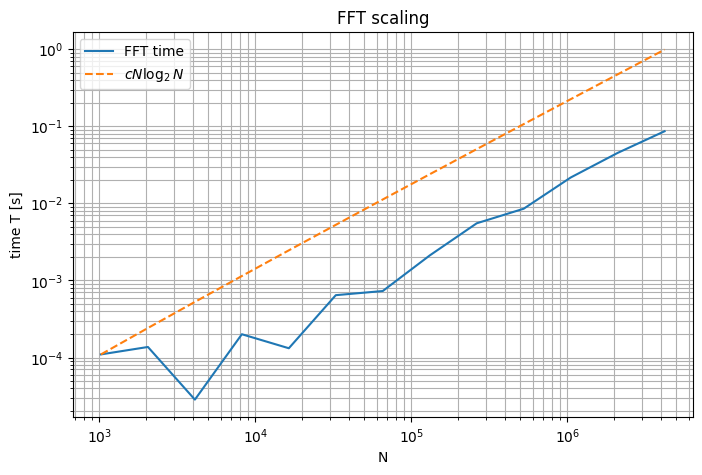

In [267]:
reference = N_list * np.log2(N_list)

c = times[0] / reference[0]
reference_scaled = c * reference

plt.figure(figsize=(8,5))
plt.loglog(N_list, times, label="FFT time")
plt.loglog(N_list, reference_scaled, "--", label=r"$cN\log_2N$")
plt.xlabel("N")
plt.ylabel("time T [s]")
plt.title("FFT scaling")
plt.legend()
plt.grid(True, which="both")
plt.show()

In [268]:
big_N = 2**20
big_N2 = 1000003 #prime

rand1 = np.random.rand(big_N)
rand2 = np.random.rand(big_N2)

start1 = time.perf_counter()
np.fft.fft(rand1)
end1 = time.perf_counter()

start2 = time.perf_counter()
np.fft.fft(rand2)
end2 = time.perf_counter()

t1 = end1 - start1
t2 = end2 - start2

(t1, t2)



(0.021545124998738174, 0.0798852080006327)

Composite transforms can be decomposed into smaller transforms however the prime number makes it a slower process for the COoley Tukey algorithm.